=== ZND reference ===
D_CJ                       = 6.415008470922
reaction length (10%-90%) = 40.70515646
reaction length (5%-95%)  = 55.90595739
s(lambda=0.5)             = 13.84532009
s(lambda=0.9)             = 43.20641311
q_end/c_end               = 0.999996709958

=== Front-speed sensitivity to fitting window ===
------------------------------------------------------------------------------------------
   t_fit_min        D_shock       D_lambda           D_CJ     D_shock-D_CJ      shock_rms     lambda_rms
------------------------------------------------------------------------------------------
       8.000     6.61037116     6.78605168     6.41500847       0.19536269   1.362093e+00   2.410014e+00
      10.000     6.64674992     6.88296210     6.41500847       0.23174145   1.182406e+00   1.425470e+00
      12.000     6.68292008     6.95172967     6.41500847       0.26791161   1.012784e+00   6.198787e-01
      15.000     6.73650541     6.97044933     6.41500847       0.32149694   7

/tmp/ipykernel_2023/170408888.py:942: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.abs(num - ref), s)
/tmp/ipykernel_2023/170408888.py:946: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.sqrt(np.trapz((num - ref) ** 2, s))


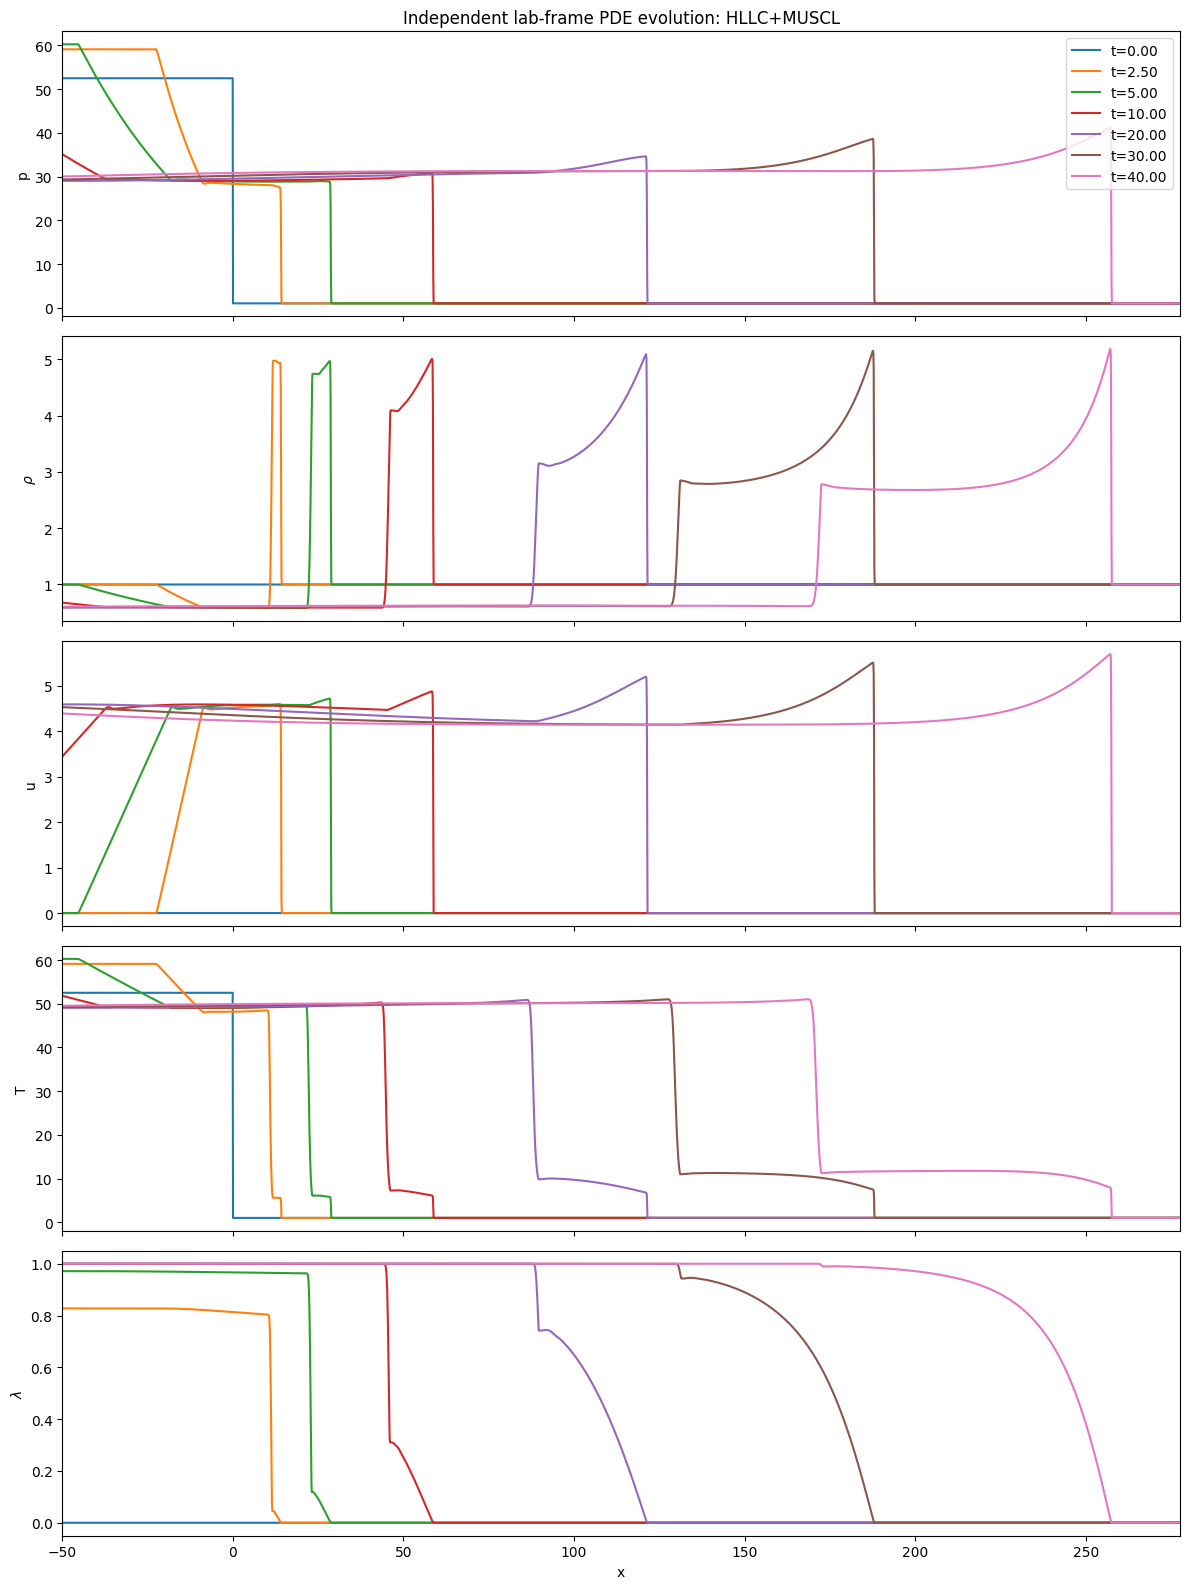

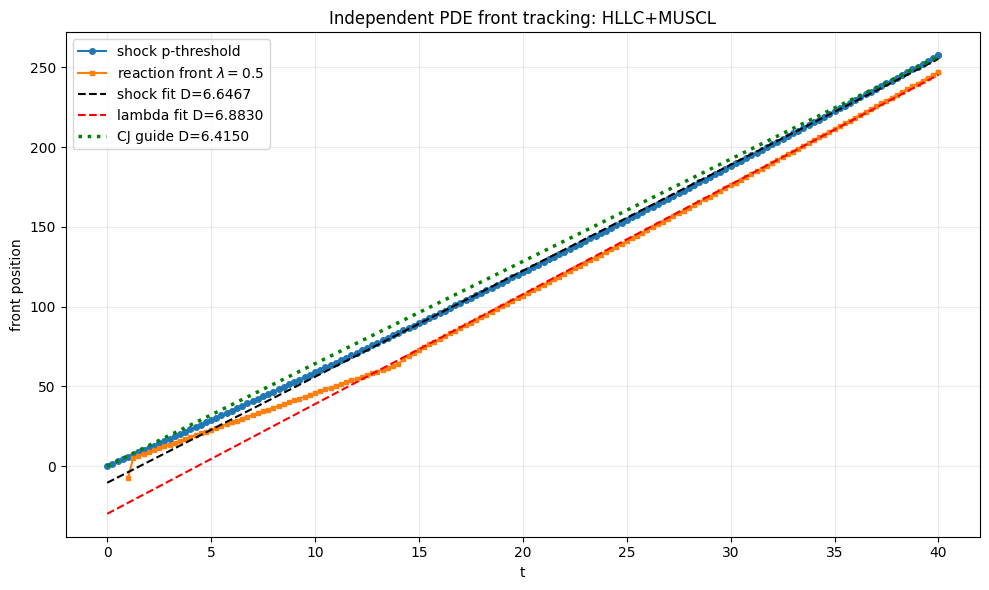

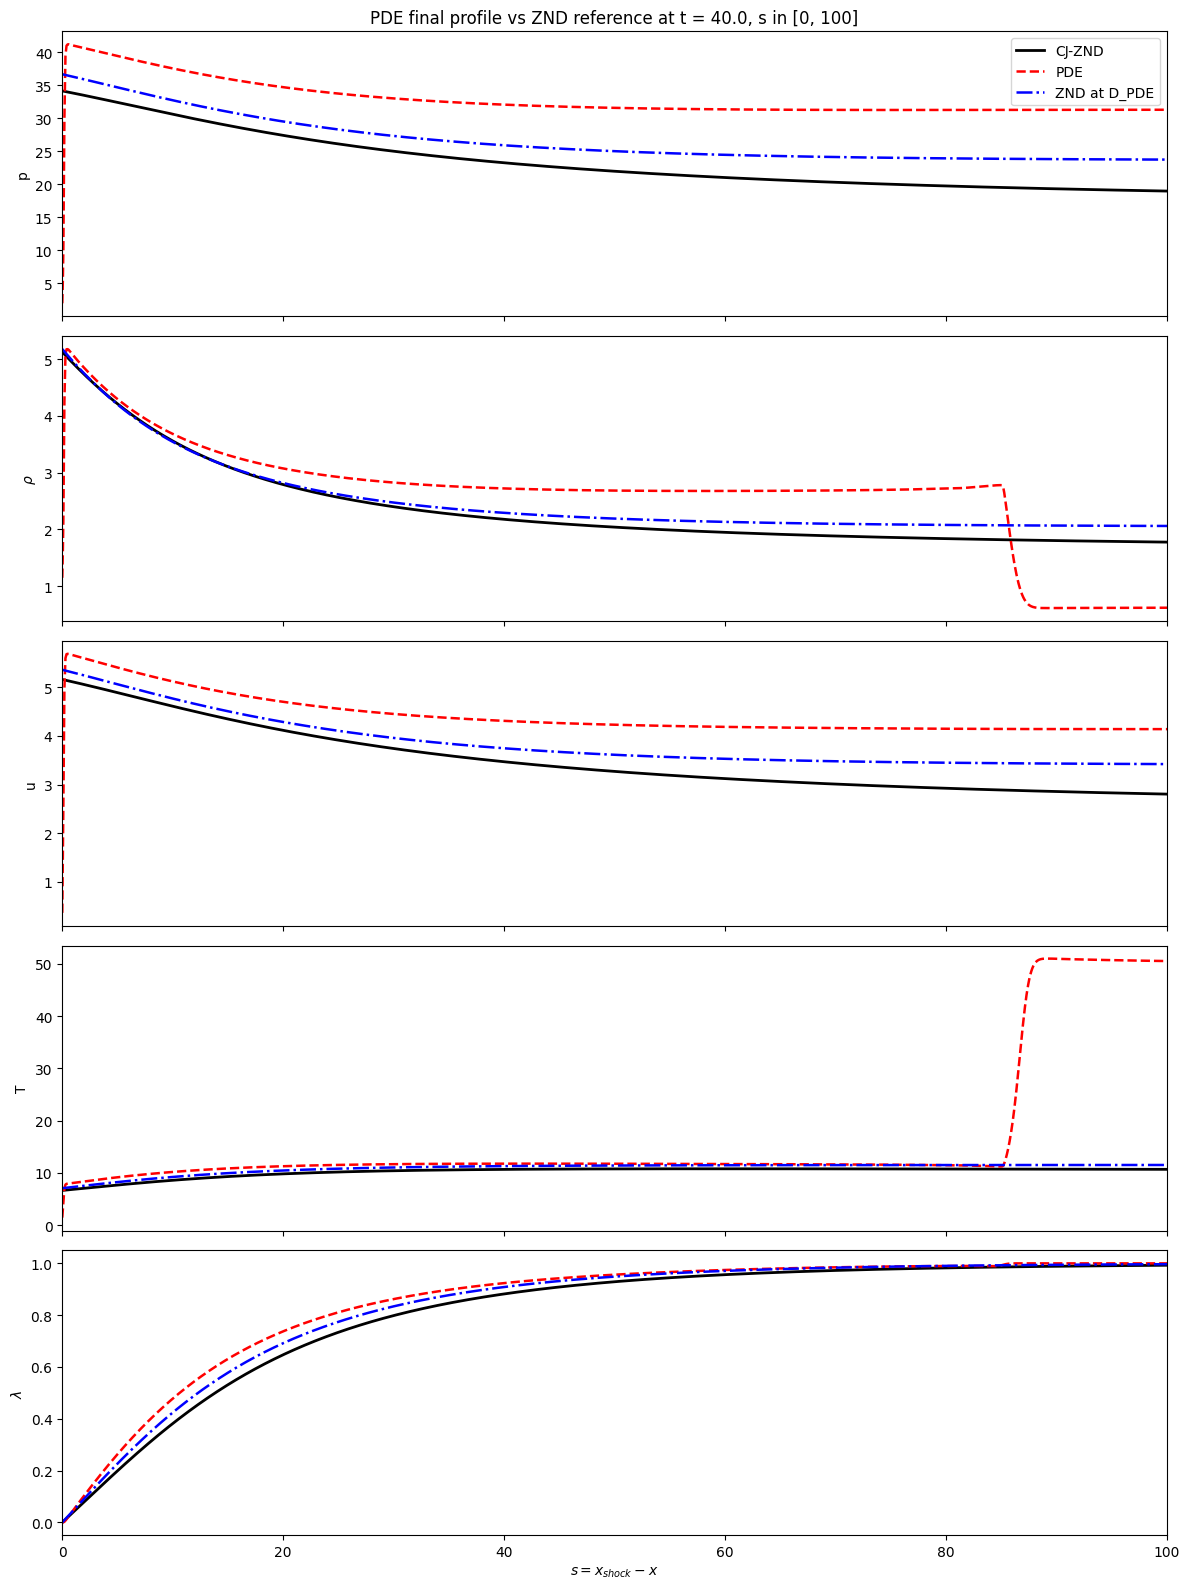

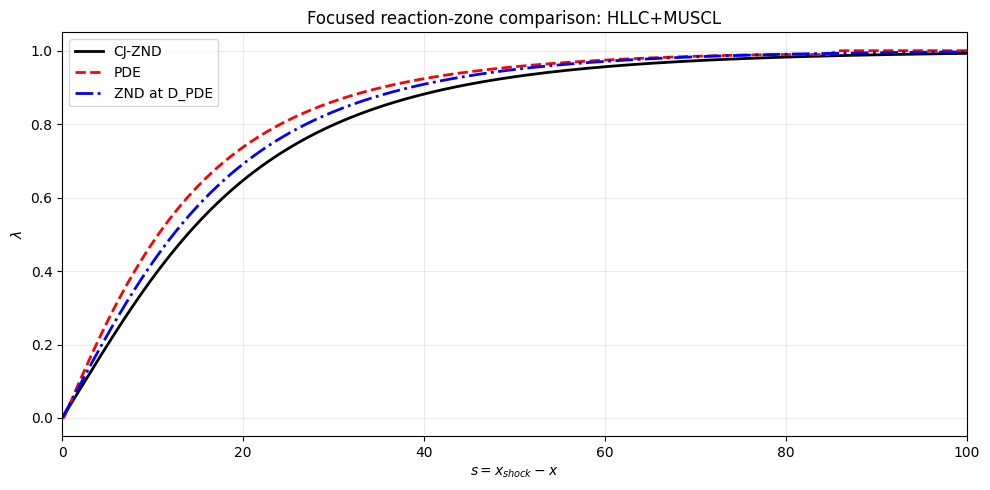

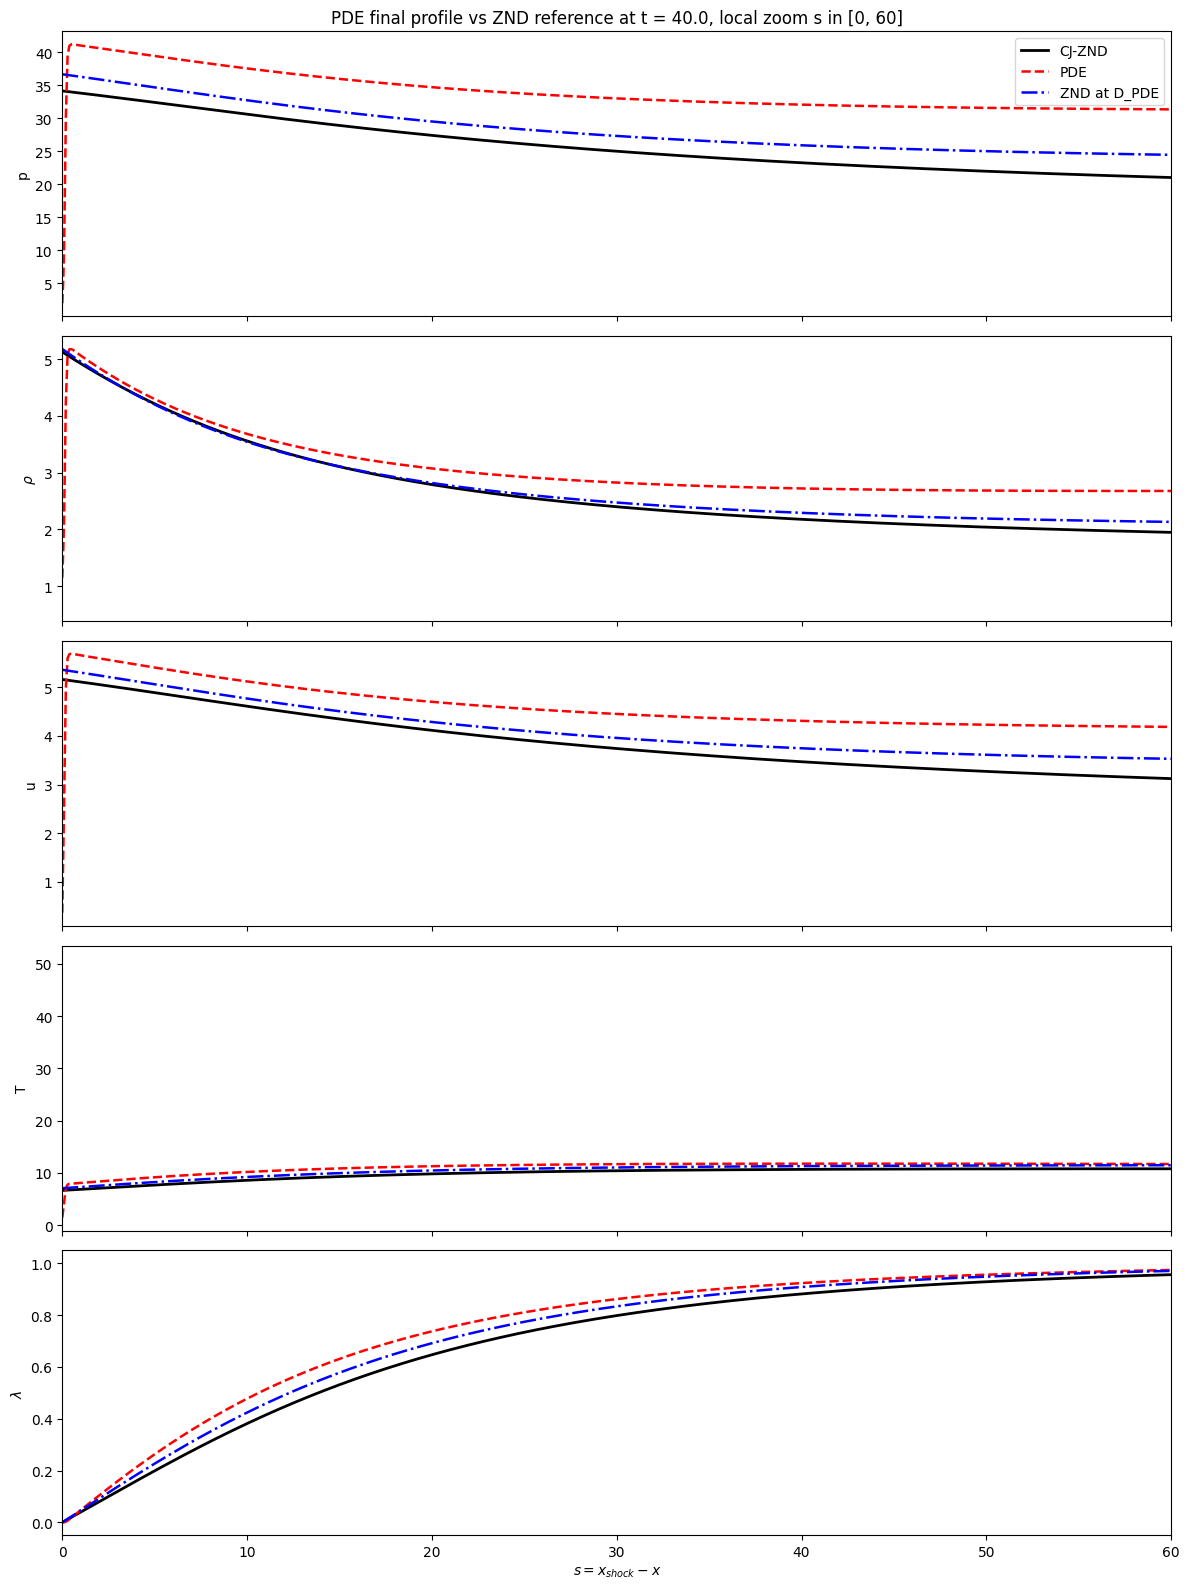

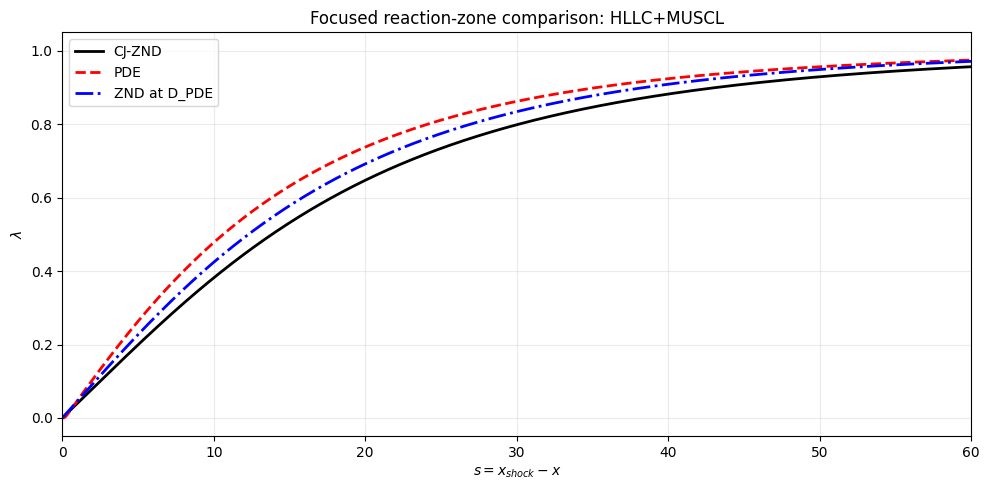


=== Independent ignition driver sweep: HLLC+MUSCL ===
----------------------------------------------------------------------------------------------------------------
     p_ign        D_shock       D_lambda           D_CJ     D_shock-D_CJ      shock_rms     lambda_rms
----------------------------------------------------------------------------------------------------------------
    50.000       6.088123       5.526157       6.415008        -0.326885   1.900208e-01   2.119316e+00
    52.500       6.242939       5.921959       6.415008        -0.172069   2.003192e-01   2.075444e+00
    55.000       6.393010       6.261957       6.415008        -0.021998   2.179491e-01   1.855214e+00
    57.500       6.538985       6.547306       6.415008         0.123976   2.240081e-01   1.549822e+00
    60.000       6.680541       6.788271       6.415008         0.265533   2.352277e-01   1.262659e+00
    62.500       6.819295       6.988833       6.415008         0.404287   2.369097e-01   9.611469e-0

In [ ]:
# MODERN SOLVER: independent ignition + ZND validation
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import math





# ZND reference solver


class ZNDFailure(Exception):
    def __init__(self, lam_fail, last_state=None, message="ZND profile terminated before lam_end"):
        super().__init__(message)
        self.lam_fail = lam_fail
        self.last_state = last_state


@dataclass
class Params:
    gamma: float = 1.4
    Q: float = 20.0
    k: float = 1.0
    Ea: float = 20.0
    R: float = 1.0

    rho_a: float = 1.0
    u_a: float = 0.0
    p_a: float = 1.0
    lam_a: float = 0.0

    n_lam: int = 4000
    lam_end: float = 1.0 - 1.0e-6

    D_bracket_low: float = 1.3
    D_bracket_high: float = 7.0
    cj_tol: float = 1.0e-10
    cj_max_iter: int = 80


def reaction_rate_znd(lam, T, p: Params):
    return p.k * (1.0 - lam) * np.exp(-p.Ea / (p.R * T))


def shock_jump(par: Params, D):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    q_a = D - par.u_a
    if q_a <= c_a:
        raise ValueError("D is too small: upstream state is not supersonic relative to the shock.")

    M_a = q_a / c_a

    rho_n = par.rho_a * ((par.gamma + 1.0) * M_a**2) / ((par.gamma - 1.0) * M_a**2 + 2.0)
    p_n = par.p_a * (1.0 + 2.0 * par.gamma / (par.gamma + 1.0) * (M_a**2 - 1.0))
    q_n = q_a * par.rho_a / rho_n
    u_n = D - q_n
    lam_n = par.lam_a

    m = rho_n * q_n
    P = p_n + rho_n * q_n**2
    B = par.gamma / (par.gamma - 1.0) * (p_n / rho_n) - par.Q * lam_n + 0.5 * q_n**2

    T_n = p_n / (rho_n * par.R)
    c_n = math.sqrt(par.gamma * p_n / rho_n)

    vn = {
        "rho": rho_n,
        "u": u_n,
        "q": q_n,
        "p": p_n,
        "T": T_n,
        "c": c_n,
        "lam": lam_n,
    }
    inv = {"m": m, "P": P, "B": B}
    return vn, inv


def state_from_lambda(lam, inv, par: Params, D, v_prev):
    m = inv["m"]
    P = inv["P"]
    B = inv["B"]

    a = m**2 * (par.gamma + 1.0) / (2.0 * (par.gamma - 1.0))
    b = -par.gamma * P / (par.gamma - 1.0)
    c = B + par.Q * lam

    disc = b**2 - 4.0 * a * c
    if disc < 0.0:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    sqrt_disc = math.sqrt(disc)
    roots = [(-b - sqrt_disc) / (2.0 * a), (-b + sqrt_disc) / (2.0 * a)]

    candidates = []
    for v in roots:
        if v <= 0.0:
            continue
        rho = 1.0 / v
        q = m * v
        p = P - m**2 * v
        if rho > 0.0 and q > 0.0 and p > 0.0:
            candidates.append(v)

    if not candidates:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    v = min(candidates, key=lambda x: abs(x - v_prev))

    rho = 1.0 / v
    q = m * v
    u = D - q
    p = P - m**2 * v
    T = p / (rho * par.R)
    c = math.sqrt(par.gamma * p / rho)
    M_rel = q / c
    omega = reaction_rate_znd(lam, T, par)

    return {
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "v": v,
    }


def build_znd_profile(par: Params, D):
    vn, inv = shock_jump(par, D)

    lam = np.linspace(par.lam_a, par.lam_end, par.n_lam)

    rho = np.empty_like(lam)
    u = np.empty_like(lam)
    q = np.empty_like(lam)
    p = np.empty_like(lam)
    T = np.empty_like(lam)
    c = np.empty_like(lam)
    M_rel = np.empty_like(lam)
    omega = np.empty_like(lam)
    s = np.empty_like(lam)

    v_prev = 1.0 / vn["rho"]
    last_state = None

    for i, lam_i in enumerate(lam):
        try:
            st = state_from_lambda(lam_i, inv, par, D, v_prev)
        except ZNDFailure:
            raise ZNDFailure(lam_fail=lam_i, last_state=last_state)

        v_prev = st["v"]
        last_state = st

        rho[i] = st["rho"]
        u[i] = st["u"]
        q[i] = st["q"]
        p[i] = st["p"]
        T[i] = st["T"]
        c[i] = st["c"]
        M_rel[i] = st["M_rel"]
        omega[i] = st["omega"]

    ds_dlam = q / omega
    s[0] = 0.0
    for i in range(1, len(lam)):
        dlam = lam[i] - lam[i - 1]
        s[i] = s[i - 1] + 0.5 * (ds_dlam[i] + ds_dlam[i - 1]) * dlam

    m_prof = rho * q
    P_prof = p + rho * q**2
    B_prof = par.gamma / (par.gamma - 1.0) * (p / rho) - par.Q * lam + 0.5 * q**2

    s_lam_05 = np.interp(0.5, lam, s)
    s_lam_09 = np.interp(0.9, lam, s)
    s_lam_095 = np.interp(0.95, lam, s)
    s_lam_005 = np.interp(0.05, lam, s)

    out = {
        "D": D,
        "s": s,
        "lam": lam,
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "vn_state": vn,
        "invariants": inv,
        "m_prof": m_prof,
        "P_prof": P_prof,
        "B_prof": B_prof,
        "reaction_length_10_90": np.interp(0.9, lam, s) - np.interp(0.1, lam, s),
        "reaction_length_5_95": s_lam_095 - s_lam_005,
        "reaction_length_total": s[-1],
        "s_lam_05": s_lam_05,
        "s_lam_09": s_lam_09,
        "p_max": np.max(p),
        "T_max": np.max(T),
        "q_end_over_c_end": M_rel[-1],
        "s_at_p_max": s[np.argmax(p)],
        "s_at_T_max": s[np.argmax(T)],
    }
    return out


def try_build_profile(par: Params, D):
    try:
        prof = build_znd_profile(par, D)
        return True, prof, None
    except Exception as e:
        return False, None, e


def find_cj_speed(par: Params):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    Dmin = c_a * (1.0 + 1.0e-12)

    D_low = max(par.D_bracket_low, Dmin)
    D_high = max(par.D_bracket_high, 1.1 * D_low)

    ok_low, _, _ = try_build_profile(par, D_low)
    while ok_low and D_low > Dmin * 1.000001:
        D_low = 0.5 * (D_low + Dmin)
        ok_low, _, _ = try_build_profile(par, D_low)

    if ok_low:
        raise RuntimeError("Could not find a failing lower bracket for CJ search.")

    ok_high, prof_high, _ = try_build_profile(par, D_high)
    while not ok_high:
        D_high *= 1.2
        ok_high, prof_high, _ = try_build_profile(par, D_high)

    for _ in range(par.cj_max_iter):
        D_mid = 0.5 * (D_low + D_high)
        ok_mid, prof_mid, _ = try_build_profile(par, D_mid)

        if ok_mid:
            D_high = D_mid
            prof_high = prof_mid
        else:
            D_low = D_mid

        if abs(D_high - D_low) <= par.cj_tol * max(1.0, abs(D_high)):
            break

    return {
        "D_cj": D_high,
        "D_fail": D_low,
        "D_succeed": D_high,
        "profile": prof_high,
    }



# PDE helpers

def prim_to_cons(rho, u, p, lam, gamma, Q):
    rho = np.asarray(rho)
    u = np.asarray(u)
    p = np.asarray(p)
    lam = np.asarray(lam)

    z = rho * lam
    E = p / (gamma - 1.0) + 0.5 * rho * u**2 - Q * z
    return np.column_stack((rho, rho * u, E, z))


def cons_to_prim(U, gamma, Q):
    rho = U[:, 0]
    mom = U[:, 1]
    E = U[:, 2]
    z = U[:, 3]

    if np.any(rho <= 0.0):
        raise ValueError(f"Non-positive density encountered: min(rho) = {rho.min()}")

    u = mom / rho
    lam = z / rho
    p = (gamma - 1.0) * (E - 0.5 * mom**2 / rho + Q * z)

    if np.any(p <= 0.0):
        raise ValueError(f"Non-positive pressure encountered: min(p) = {p.min()}")

    return rho, u, p, lam


def flux(U, gamma, Q):
    rho, u, p, _ = cons_to_prim(U, gamma, Q)
    mom = U[:, 1]
    E = U[:, 2]
    z = U[:, 3]

    F = np.empty_like(U)
    F[:, 0] = mom
    F[:, 1] = mom * u + p
    F[:, 2] = u * (E + p)
    F[:, 3] = u * z
    return F


def flux_moving(U, gamma, Q, Dref):

    return Dref * U - flux(U, gamma, Q)


def flux_fminusdu(U, gamma, Q, Dref):

    return flux(U, gamma, Q) - Dref * U


def temperature_from_prim(rho, p, Rgas):
    return p / (rho * Rgas)


def reaction_rate_from_prim(rho, p, lam, k, Ea, Rgas):
    T = np.maximum(p / (rho * Rgas), 1.0e-14)
    lam_clip = np.clip(lam, 0.0, 1.0)
    return k * (1.0 - lam_clip) * np.exp(-Ea / (Rgas * T))


def apply_dirichlet_bc(U, left_state_cons, right_state_cons):
    U[0, :] = left_state_cons
    U[-1, :] = right_state_cons



# HLLC flux in shock-attached frame


def _safe_denom(x, eps=1.0e-14):
    return np.where(np.abs(x) < eps, eps * np.where(x >= 0.0, 1.0, -1.0), x)


def hllc_flux_fminusdu_array(UL, UR, gamma, Q, Dref):

    rhoL, uL, pL, lamL = cons_to_prim(UL, gamma, Q)
    rhoR, uR, pR, lamR = cons_to_prim(UR, gamma, Q)

    EL = UL[:, 2]
    ER = UR[:, 2]

    qL = uL - Dref
    qR = uR - Dref

    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)

    FL = flux_fminusdu(UL, gamma, Q, Dref)
    FR = flux_fminusdu(UR, gamma, Q, Dref)

    SL = np.minimum(qL - aL, qR - aR)
    SR = np.maximum(qL + aL, qR + aR)

    denom = rhoL * (SL - qL) - rhoR * (SR - qR)
    denom = _safe_denom(denom)

    Sstar = (
        pR - pL
        + rhoL * qL * (SL - qL)
        - rhoR * qR * (SR - qR)
    ) / denom

    SLmS = _safe_denom(SL - Sstar)
    SRmS = _safe_denom(SR - Sstar)

    rho_star_L = rhoL * (SL - qL) / SLmS
    rho_star_R = rhoR * (SR - qR) / SRmS

    u_star_lab = Sstar + Dref

    mom_star_L = rho_star_L * u_star_lab
    mom_star_R = rho_star_R * u_star_lab


    p_star_L = pL + rhoL * (SL - qL) * (Sstar - qL)
    p_star_R = pR + rhoR * (SR - qR) * (Sstar - qR)


    E_star_L = ((SL - qL) * EL - uL * pL + u_star_lab * p_star_L) / SLmS
    E_star_R = ((SR - qR) * ER - uR * pR + u_star_lab * p_star_R) / SRmS

    z_star_L = rho_star_L * lamL
    z_star_R = rho_star_R * lamR

    U_star_L = np.column_stack((rho_star_L, mom_star_L, E_star_L, z_star_L))
    U_star_R = np.column_stack((rho_star_R, mom_star_R, E_star_R, z_star_R))

    F_star_L = FL + SL[:, None] * (U_star_L - UL)
    F_star_R = FR + SR[:, None] * (U_star_R - UR)

    Fhat = np.empty_like(FL)

    mask_L = SL >= 0.0
    mask_star_L = (SL < 0.0) & (Sstar >= 0.0)
    mask_star_R = (Sstar < 0.0) & (SR > 0.0)
    mask_R = SR <= 0.0

    Fhat[mask_L] = FL[mask_L]
    Fhat[mask_star_L] = F_star_L[mask_star_L]
    Fhat[mask_star_R] = F_star_R[mask_star_R]
    Fhat[mask_R] = FR[mask_R]

    return Fhat


def hllc_flux_moving_array(UL, UR, gamma, Q, Dref):

    return -hllc_flux_fminusdu_array(UR, UL, gamma, Q, Dref)



# MUSCL reconstruction


def minmod3(a, b, c):
    s = 0.25 * np.abs(np.sign(a) + np.sign(b)) * (np.sign(a) + np.sign(c))
    return s * np.minimum(np.abs(a), np.minimum(np.abs(b), np.abs(c)))


def mc_limiter(dm, dp):
    return minmod3(0.5 * (dm + dp), 2.0 * dm, 2.0 * dp)


def reconstruct_muscl_primitive(Uc, gamma, Q):
    W = np.column_stack(cons_to_prim(Uc, gamma, Q))

    dminus = W[1:-1, :] - W[:-2, :]
    dplus = W[2:, :] - W[1:-1, :]
    slope = mc_limiter(dminus, dplus)

    WL_cell = W[1:-1, :] - 0.5 * slope
    WR_cell = W[1:-1, :] + 0.5 * slope

    eps = 1.0e-12
    WL_cell[:, 0] = np.maximum(WL_cell[:, 0], eps)
    WR_cell[:, 0] = np.maximum(WR_cell[:, 0], eps)
    WL_cell[:, 2] = np.maximum(WL_cell[:, 2], eps)
    WR_cell[:, 2] = np.maximum(WR_cell[:, 2], eps)
    WL_cell[:, 3] = np.clip(WL_cell[:, 3], 0.0, 1.0)
    WR_cell[:, 3] = np.clip(WR_cell[:, 3], 0.0, 1.0)

    UL_cell = prim_to_cons(WL_cell[:, 0], WL_cell[:, 1], WL_cell[:, 2], WL_cell[:, 3], gamma, Q)
    UR_cell = prim_to_cons(WR_cell[:, 0], WR_cell[:, 1], WR_cell[:, 2], WR_cell[:, 3], gamma, Q)

    ncells = Uc.shape[0] - 2
    n_interfaces = Uc.shape[0] - 1

    UL_rec = np.zeros((n_interfaces, 4))
    UR_rec = np.zeros((n_interfaces, 4))

    UL_rec[1:ncells, :] = UR_cell[:-1, :]
    UR_rec[1:ncells, :] = UL_cell[1:, :]

    UL_rec[0, :] = Uc[0, :]
    UR_rec[0, :] = UL_cell[0, :]

    UL_rec[ncells, :] = UR_cell[-1, :]
    UR_rec[ncells, :] = Uc[-1, :]

    return UL_rec, UR_rec




# Laboratory-frame HLLC/MUSCL reactive solver


def apply_outflow_bc(U):
    U[0, :] = U[1, :]
    U[-1, :] = U[-2, :]


def hllc_flux_lab_array(UL, UR, gamma, Q):

    return hllc_flux_fminusdu_array(UL, UR, gamma, Q, Dref=0.0)


def rhs_euler_hllc_first_order_lab(U, dx, gamma, Q):
    Uc = U.copy()
    apply_outflow_bc(Uc)

    UL = Uc[:-1, :]
    UR = Uc[1:, :]
    Fhat = hllc_flux_lab_array(UL, UR, gamma, Q)

    rhs = np.zeros_like(Uc)
    rhs[1:-1, :] = -(Fhat[1:, :] - Fhat[:-1, :]) / dx
    return rhs


def rhs_euler_hllc_muscl_lab(U, dx, gamma, Q):
    Uc = U.copy()
    apply_outflow_bc(Uc)

    UL_rec, UR_rec = reconstruct_muscl_primitive(Uc, gamma, Q)
    Fhat = hllc_flux_lab_array(UL_rec, UR_rec, gamma, Q)

    rhs = np.zeros_like(Uc)
    rhs[1:-1, :] = -(Fhat[1:, :] - Fhat[:-1, :]) / dx
    return rhs


def max_wave_speed_lab(U, gamma, Q):
    rho, u, p, _ = cons_to_prim(U[1:-1, :], gamma, Q)
    c = np.sqrt(gamma * p / rho)
    return np.max(np.abs(u) + c)


def compute_dt_lab(U, dx, cfl, gamma, Q):
    amax = max_wave_speed_lab(U, gamma, Q)
    return cfl * dx / amax


def ssprk3_step_lab(U, dt, dx, gamma, Q, use_muscl=True):
    rhs_func = rhs_euler_hllc_muscl_lab if use_muscl else rhs_euler_hllc_first_order_lab

    U0 = U.copy()
    apply_outflow_bc(U0)

    K1 = rhs_func(U0, dx, gamma, Q)
    U1 = U0.copy()
    U1[1:-1, :] = U0[1:-1, :] + dt * K1[1:-1, :]
    apply_outflow_bc(U1)

    K2 = rhs_func(U1, dx, gamma, Q)
    U2 = U1.copy()
    U2[1:-1, :] = 0.75 * U0[1:-1, :] + 0.25 * (U1[1:-1, :] + dt * K2[1:-1, :])
    apply_outflow_bc(U2)

    K3 = rhs_func(U2, dx, gamma, Q)
    U3 = U2.copy()
    U3[1:-1, :] = (1.0 / 3.0) * U0[1:-1, :] + (2.0 / 3.0) * (U2[1:-1, :] + dt * K3[1:-1, :])
    apply_outflow_bc(U3)

    return U3



# Reaction step and Strang splitting with outflow boundaries


def reaction_step_outflow(U, dt, gamma, Q, k, Ea, Rgas, react_cfl=0.2, max_substeps=20000):

    Uwork = U.copy()
    apply_outflow_bc(Uwork)

    remaining = dt
    nsub = 0

    while remaining > 1.0e-15:
        rho, u, p, lam = cons_to_prim(Uwork[1:-1, :], gamma, Q)
        omega = reaction_rate_from_prim(rho, p, lam, k, Ea, Rgas)
        omega_max = np.max(omega)

        if omega_max < 1.0e-14:
            break

        dtau = min(remaining, react_cfl / omega_max)

        accepted = False
        for _ in range(20):
            z_old = Uwork[1:-1, 3].copy()
            z_new = z_old + dtau * rho * omega
            lam_new = np.clip(z_new / rho, 0.0, 1.0)
            z_new = rho * lam_new

            Utrial = Uwork.copy()
            Utrial[1:-1, 3] = z_new

            try:
                _ = cons_to_prim(Utrial[1:-1, :], gamma, Q)
                accepted = True
                Uwork = Utrial
                remaining -= dtau
                break
            except ValueError:
                dtau *= 0.5

        if not accepted:
            raise RuntimeError("Reaction step failed to preserve positivity.")

        nsub += 1
        if nsub > max_substeps:
            raise RuntimeError("Too many reaction substeps. Try smaller dt or weaker reaction.")

    apply_outflow_bc(Uwork)
    return Uwork


def strang_step_lab_hllc(U, dt, dx, gamma, Q, k, Ea, Rgas, react_cfl=0.2, use_muscl=True):
    U1 = reaction_step_outflow(
        U, 0.5 * dt, gamma, Q, k, Ea, Rgas,
        react_cfl=react_cfl
    )
    U2 = ssprk3_step_lab(
        U1, dt, dx, gamma, Q,
        use_muscl=use_muscl
    )
    U3 = reaction_step_outflow(
        U2, 0.5 * dt, gamma, Q, k, Ea, Rgas,
        react_cfl=react_cfl
    )
    return U3




def initialize_independent_ignition(
    x,
    par: Params,
    x_ign_left=-50.0,
    x_ign_right=0.0,
    rho_ign=1.0,
    u_ign=0.0,
    p_ign=52.5,
    lam_ign=0.0,
    smooth=False,
    smooth_width=1.0,
):

    rho = np.full_like(x, par.rho_a, dtype=float)
    u = np.full_like(x, par.u_a, dtype=float)
    p = np.full_like(x, par.p_a, dtype=float)
    lam = np.full_like(x, par.lam_a, dtype=float)

    if not smooth:
        mask = (x >= x_ign_left) & (x <= x_ign_right)
        rho[mask] = rho_ign
        u[mask] = u_ign
        p[mask] = p_ign
        lam[mask] = lam_ign
    else:

        w = smooth_width
        left = 0.5 * (1.0 + np.tanh((x - x_ign_left) / w))
        right = 0.5 * (1.0 - np.tanh((x - x_ign_right) / w))
        chi = left * right
        rho = par.rho_a + chi * (rho_ign - par.rho_a)
        u = par.u_a + chi * (u_ign - par.u_a)
        p = par.p_a + chi * (p_ign - par.p_a)
        lam = par.lam_a + chi * (lam_ign - par.lam_a)

    U = prim_to_cons(rho, u, p, lam, par.gamma, par.Q)
    return U


def shock_position_pressure_threshold(x, U, par: Params, p_level=2.0):

    _, _, p, _ = cons_to_prim(U, par.gamma, par.Q)
    f = p - p_level

    idx = np.where((f[:-1] <= 0.0) & (f[1:] > 0.0))[0]
    if len(idx) == 0:
        idx = np.where((f[:-1] >= 0.0) & (f[1:] < 0.0))[0]

    if len(idx) == 0:
        mask = p > p_level
        if np.any(mask):
            return x[np.where(mask)[0][-1]]
        return np.nan

    i = idx[-1]
    x0, x1 = x[i], x[i + 1]
    f0, f1 = f[i], f[i + 1]
    if abs(f1 - f0) < 1.0e-14:
        return 0.5 * (x0 + x1)
    return x0 - f0 * (x1 - x0) / (f1 - f0)


def lambda_position_level(x, U, par: Params, level=0.5):

    _, _, _, lam = cons_to_prim(U, par.gamma, par.Q)
    f = lam - level

    idx = np.where((f[:-1] >= 0.0) & (f[1:] < 0.0))[0]
    if len(idx) == 0:
        idx = np.where((f[:-1] <= 0.0) & (f[1:] > 0.0))[0]

    if len(idx) == 0:
        return np.nan

    i = idx[-1]
    x0, x1 = x[i], x[i + 1]
    f0, f1 = f[i], f[i + 1]
    if abs(f1 - f0) < 1.0e-14:
        return 0.5 * (x0 + x1)
    return x0 - f0 * (x1 - x0) / (f1 - f0)


def fit_front_speed(trajectory, t_min=10.0, use_lambda_front=False):
    arr = []
    for item in trajectory:
        t = item["t"]
        xfront = item["x_lam05"] if use_lambda_front else item["x_shock"]
        if t >= t_min and np.isfinite(xfront):
            arr.append((t, xfront))

    if len(arr) < 2:
        return np.nan, np.nan, np.nan, None

    arr = np.asarray(arr)
    tt = arr[:, 0]
    xx = arr[:, 1]

    coeff = np.polyfit(tt, xx, 1)
    D = coeff[0]
    b = coeff[1]
    xx_fit = D * tt + b
    rms = np.sqrt(np.mean((xx - xx_fit) ** 2))
    return D, b, rms, arr


def solve_independent_reactive_hllc(
    par: Params,
    xL=-50.0,
    xR=380.0,
    N=4300,
    final_time=40.0,
    cfl=0.2,
    react_cfl=0.2,
    ignition_kwargs=None,
    snapshot_times=None,
    tracking_dt=0.25,
    use_muscl=True,
):
    if ignition_kwargs is None:
        ignition_kwargs = {}
    if snapshot_times is None:
        snapshot_times = []

    dx = (xR - xL) / N
    x = xL + (np.arange(N) + 0.5) * dx

    U_phys = initialize_independent_ignition(x, par, **ignition_kwargs)

    U = np.zeros((N + 2, 4))
    U[1:-1, :] = U_phys
    apply_outflow_bc(U)

    t = 0.0
    snapshots = []
    snapshot_times = sorted(snapshot_times)
    next_snapshot = 0

    trajectory = []
    next_tracking_time = 0.0

    while t < final_time - 1.0e-14:
        dt = compute_dt_lab(U, dx, cfl, par.gamma, par.Q)
        dt = min(dt, final_time - t)

        if next_snapshot < len(snapshot_times):
            dt = min(dt, snapshot_times[next_snapshot] - t)

        if t + dt >= next_tracking_time - 1.0e-14:
            x_shock = shock_position_pressure_threshold(x, U[1:-1, :], par, p_level=2.0)
            x_lam05 = lambda_position_level(x, U[1:-1, :], par, level=0.5)
            trajectory.append({"t": t, "x_shock": x_shock, "x_lam05": x_lam05})
            next_tracking_time += tracking_dt

        if dt <= 1.0e-15:

            if next_snapshot < len(snapshot_times) and abs(t - snapshot_times[next_snapshot]) < 1.0e-12:
                snapshots.append((t, U[1:-1, :].copy()))
                next_snapshot += 1
                continue
            break

        U = strang_step_lab_hllc(
            U,
            dt,
            dx,
            par.gamma,
            par.Q,
            par.k,
            par.Ea,
            par.R,
            react_cfl=react_cfl,
            use_muscl=use_muscl,
        )

        t += dt

        while next_snapshot < len(snapshot_times) and t >= snapshot_times[next_snapshot] - 1.0e-12:
            snapshots.append((snapshot_times[next_snapshot], U[1:-1, :].copy()))
            next_snapshot += 1

    x_shock = shock_position_pressure_threshold(x, U[1:-1, :], par, p_level=2.0)
    x_lam05 = lambda_position_level(x, U[1:-1, :], par, level=0.5)
    trajectory.append({"t": final_time, "x_shock": x_shock, "x_lam05": x_lam05})

    return x, U[1:-1, :].copy(), snapshots, trajectory



# Shock-attached profile extraction and ZND comparison


def extract_pde_profile_behind_shock(x, U, par: Params, x_shock, s_max=120.0, n_points=2500):
    rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)
    T = temperature_from_prim(rho, p, par.R)

    s_sample = np.linspace(0.0, s_max, n_points)
    x_sample = x_shock - s_sample


    rho_s = np.interp(x_sample, x, rho)
    u_s = np.interp(x_sample, x, u)
    p_s = np.interp(x_sample, x, p)
    T_s = np.interp(x_sample, x, T)
    lam_s = np.interp(x_sample, x, lam)

    omega_s = reaction_rate_from_prim(rho_s, p_s, lam_s, par.k, par.Ea, par.R)

    return {
        "s": s_sample,
        "rho": rho_s,
        "u": u_s,
        "p": p_s,
        "T": T_s,
        "lam": lam_s,
        "omega": omega_s,
    }


def znd_profile_on_s_grid(prof, s_grid):
    return {
        "s": s_grid,
        "rho": np.interp(s_grid, prof["s"], prof["rho"]),
        "u": np.interp(s_grid, prof["s"], prof["u"]),
        "p": np.interp(s_grid, prof["s"], prof["p"]),
        "T": np.interp(s_grid, prof["s"], prof["T"]),
        "lam": np.interp(s_grid, prof["s"], prof["lam"]),
        "omega": np.interp(s_grid, prof["s"], prof["omega"]),
    }


def reaction_zone_metrics_from_profile(profile):
    s = profile["s"]
    lam = profile["lam"]

    def crossing(level):
        f = lam - level
        idx = np.where((f[:-1] <= 0.0) & (f[1:] >= 0.0))[0]
        if len(idx) == 0:
            return np.nan
        i = idx[0]
        s0, s1 = s[i], s[i + 1]
        f0, f1 = f[i], f[i + 1]
        if abs(f1 - f0) < 1.0e-14:
            return 0.5 * (s0 + s1)
        return s0 - f0 * (s1 - s0) / (f1 - f0)

    s05 = crossing(0.05)
    s10 = crossing(0.10)
    s50 = crossing(0.50)
    s90 = crossing(0.90)
    s95 = crossing(0.95)

    return {
        "s05": s05,
        "s10": s10,
        "s50": s50,
        "s90": s90,
        "s95": s95,
        "L10_90": s90 - s10 if np.isfinite(s90) and np.isfinite(s10) else np.nan,
        "L5_95": s95 - s05 if np.isfinite(s95) and np.isfinite(s05) else np.nan,
    }


def l1_error_on_s(num, ref, s):
    return np.trapz(np.abs(num - ref), s)


def l2_error_on_s(num, ref, s):
    return np.sqrt(np.trapz((num - ref) ** 2, s))


def linf_error_on_s(num, ref):
    return np.max(np.abs(num - ref))


def profile_error_report(pde_prof, znd_prof, smooth_window=(1.0, 80.0)):
    s = pde_prof["s"]
    mask = (s >= smooth_window[0]) & (s <= smooth_window[1])

    out = {}
    for key in ["p", "rho", "u", "T", "lam"]:
        num = pde_prof[key]
        ref = znd_prof[key]

        out[f"{key}_full"] = {
            "L1": l1_error_on_s(num, ref, s),
            "L2": l2_error_on_s(num, ref, s),
            "Linf": linf_error_on_s(num, ref),
        }

        out[f"{key}_smooth"] = {
            "L1": l1_error_on_s(num[mask], ref[mask], s[mask]),
            "L2": l2_error_on_s(num[mask], ref[mask], s[mask]),
            "Linf": linf_error_on_s(num[mask], ref[mask]),
        }

    return out



# Plotting and diagnostics


def plot_lab_snapshots(x, snapshots, par: Params, xlim=None):
    fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

    for t, U in snapshots:
        rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)
        T = temperature_from_prim(rho, p, par.R)
        label = f"t={t:.2f}"

        axes[0].plot(x, p, lw=1.5, label=label)
        axes[1].plot(x, rho, lw=1.5)
        axes[2].plot(x, u, lw=1.5)
        axes[3].plot(x, T, lw=1.5)
        axes[4].plot(x, lam, lw=1.5)

    axes[0].set_title("Independent lab-frame PDE evolution: HLLC+MUSCL")
    axes[0].set_ylabel("p")
    axes[1].set_ylabel(r"$\rho$")
    axes[2].set_ylabel("u")
    axes[3].set_ylabel("T")
    axes[4].set_ylabel(r"$\lambda$")
    axes[4].set_xlabel("x")

    axes[0].legend(loc="best")
    if xlim is not None:
        axes[-1].set_xlim(*xlim)

    plt.tight_layout()
    plt.show()


def plot_front_trajectory(trajectory, D_cj, t_fit_min=10.0):
    t = np.array([q["t"] for q in trajectory])
    xs = np.array([q["x_shock"] for q in trajectory])
    xl = np.array([q["x_lam05"] for q in trajectory])

    D_shock, b_shock, _, arr_s = fit_front_speed(trajectory, t_min=t_fit_min, use_lambda_front=False)
    D_lam, b_lam, _, arr_l = fit_front_speed(trajectory, t_min=t_fit_min, use_lambda_front=True)

    plt.figure(figsize=(10, 6))
    plt.plot(t, xs, "o-", ms=4, label="shock p-threshold")
    plt.plot(t, xl, "s-", ms=3, label=r"reaction front $\lambda=0.5$")

    tt = np.linspace(np.nanmin(t), np.nanmax(t), 200)
    if np.isfinite(D_shock):
        plt.plot(tt, D_shock * tt + b_shock, "k--", label=f"shock fit D={D_shock:.4f}")
    if np.isfinite(D_lam):
        plt.plot(tt, D_lam * tt + b_lam, "r--", label=f"lambda fit D={D_lam:.4f}")


    finite = np.isfinite(xs)
    if np.any(finite):
        i0 = np.where(finite)[0][0]
        plt.plot(tt, xs[i0] + D_cj * (tt - t[i0]), "g:", lw=2.5, label=f"CJ guide D={D_cj:.4f}")

    plt.title("Independent PDE front tracking: HLLC+MUSCL")
    plt.xlabel("t")
    plt.ylabel("front position")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_pde_vs_znd_profile(pde_prof, znd_cj, znd_speed=None, title_suffix="", xlim=(0.0, 100.0)):
    s = pde_prof["s"]
    fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

    fields = ["p", "rho", "u", "T", "lam"]
    labels = ["p", r"$\rho$", "u", "T", r"$\lambda$"]

    for ax, key, lab in zip(axes, fields, labels):
        ax.plot(s, znd_cj[key], "k-", lw=2.0, label="CJ-ZND" if key == "p" else None)
        ax.plot(s, pde_prof[key], "r--", lw=1.8, label="PDE" if key == "p" else None)

        if znd_speed is not None:
            ax.plot(s, znd_speed[key], "b-.", lw=1.8, label="ZND at D_PDE" if key == "p" else None)

        ax.set_ylabel(lab)

    axes[0].set_title(f"PDE final profile vs ZND reference {title_suffix}")
    axes[-1].set_xlabel(r"$s = x_{shock} - x$")
    axes[0].legend(loc="best")
    axes[-1].set_xlim(*xlim)
    plt.tight_layout()
    plt.show()


def plot_lambda_profile_focus(pde_prof, znd_cj, znd_speed=None, xlim=(0.0, 100.0)):
    s = pde_prof["s"]
    plt.figure(figsize=(10, 5))
    plt.plot(s, znd_cj["lam"], "k-", lw=2.0, label="CJ-ZND")
    plt.plot(s, pde_prof["lam"], "r--", lw=2.0, label="PDE")
    if znd_speed is not None:
        plt.plot(s, znd_speed["lam"], "b-.", lw=2.0, label="ZND at D_PDE")
    plt.xlim(*xlim)
    plt.ylim(-0.05, 1.05)
    plt.xlabel(r"$s = x_{shock} - x$")
    plt.ylabel(r"$\lambda$")
    plt.title("Focused reaction-zone comparison: HLLC+MUSCL")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def print_window_error_table(title, errs):
    print(f"\n{title}")
    print("-" * 86)
    print(f"{'var':>6} {'L1(window)':>18} {'L2(window)':>18} {'Linf(window)':>18}")
    print("-" * 86)
    for var in ["p", "rho", "u", "T", "lam"]:
        e = errs[f"{var}_smooth"]
        print(f"{var:>6} {e['L1']:18.8e} {e['L2']:18.8e} {e['Linf']:18.8e}")
    print("-" * 86)


def independent_driver_sweep(
    par: Params,
    cj,
    p_ign_values,
    xL=-50.0,
    xR=380.0,
    N=1200,
    final_time=20.0,
    cfl=0.2,
    react_cfl=0.2,
    t_fit_min=8.0,
    base_ignition_kwargs=None,
    use_muscl=True,
):
    if base_ignition_kwargs is None:
        base_ignition_kwargs = {}

    print("\n=== Independent ignition driver sweep: HLLC+MUSCL ===")
    print("-" * 112)
    print(
        f"{'p_ign':>10} {'D_shock':>14} {'D_lambda':>14} {'D_CJ':>14} "
        f"{'D_shock-D_CJ':>16} {'shock_rms':>14} {'lambda_rms':>14}"
    )
    print("-" * 112)

    for p_ign in p_ign_values:
        ign = dict(base_ignition_kwargs)
        ign["p_ign"] = p_ign

        try:
            _, _, _, traj = solve_independent_reactive_hllc(
                par=par,
                xL=xL,
                xR=xR,
                N=N,
                final_time=final_time,
                cfl=cfl,
                react_cfl=react_cfl,
                ignition_kwargs=ign,
                snapshot_times=[],
                tracking_dt=0.25,
                use_muscl=use_muscl,
            )

            D_s, _, rms_s, _ = fit_front_speed(traj, t_min=t_fit_min, use_lambda_front=False)
            D_l, _, rms_l, _ = fit_front_speed(traj, t_min=t_fit_min, use_lambda_front=True)

            print(
                f"{p_ign:10.3f} {D_s:14.6f} {D_l:14.6f} {cj['D_cj']:14.6f} "
                f"{D_s - cj['D_cj']:16.6f} {rms_s:14.6e} {rms_l:14.6e}"
            )

        except Exception as e:
            print(f"{p_ign:10.3f} {'FAILED':>14}   reason: {e}")

    print("-" * 112)



# Main script


def main():

    par = Params(
        gamma=1.4,
        Q=20.0,
        k=1.0,
        Ea=20.0,
        R=1.0,
        rho_a=1.0,
        u_a=0.0,
        p_a=1.0,
        lam_a=0.0,
        n_lam=4000,
        lam_end=1.0 - 1.0e-6,
        D_bracket_low=1.3,
        D_bracket_high=7.0,
        cj_tol=1.0e-10,
        cj_max_iter=80,
    )

    use_muscl = True
    solver_name = "HLLC+MUSCL" if use_muscl else "HLLC first-order"


    cj = find_cj_speed(par)
    prof_cj = cj["profile"]

    print("=== ZND reference ===")
    print(f"D_CJ                       = {cj['D_cj']:.12f}")
    print(f"reaction length (10%-90%) = {prof_cj['reaction_length_10_90']:.8f}")
    print(f"reaction length (5%-95%)  = {prof_cj['reaction_length_5_95']:.8f}")
    print(f"s(lambda=0.5)             = {prof_cj['s_lam_05']:.8f}")
    print(f"s(lambda=0.9)             = {prof_cj['s_lam_09']:.8f}")
    print(f"q_end/c_end               = {prof_cj['q_end_over_c_end']:.12f}")


    xL = -50.0
    xR = 380.0
    dx_target = 0.1
    N = int(round((xR - xL) / dx_target))
    final_time = 40.0

    cfl = 0.20
    react_cfl = 0.20

    ignition_kwargs = {
        "x_ign_left": -50.0,
        "x_ign_right": 0.0,
        "rho_ign": 1.0,
        "u_ign": 0.0,
        "p_ign": 52.5,
        "lam_ign": 0.0,
        "smooth": False,
        "smooth_width": 1.0,
    }

    snapshot_times = [0.0, 2.5, 5.0, 10.0, 20.0, 30.0, 40.0]
    tracking_dt = 0.25
    t_fit_min = 10.0

    wide_error_window = (1.0, 80.0)
    local_error_window = (0.0, 60.0)


    x, U_final, snapshots, trajectory = solve_independent_reactive_hllc(
        par=par,
        xL=xL,
        xR=xR,
        N=N,
        final_time=final_time,
        cfl=cfl,
        react_cfl=react_cfl,
        ignition_kwargs=ignition_kwargs,
        snapshot_times=snapshot_times[1:],
        tracking_dt=tracking_dt,
        use_muscl=use_muscl,
    )

    U_init = initialize_independent_ignition(x, par, **ignition_kwargs)
    snapshots = [(0.0, U_init.copy())] + snapshots


    D_shock, b_shock, rms_shock, _ = fit_front_speed(
        trajectory,
        t_min=t_fit_min,
        use_lambda_front=False,
    )

    D_lambda, b_lambda, rms_lambda, _ = fit_front_speed(
        trajectory,
        t_min=t_fit_min,
        use_lambda_front=True,
    )


    t_fit_values = [8.0, 10.0, 12.0, 15.0, 20.0, 25.0, 30.0]

    print("\n=== Front-speed sensitivity to fitting window ===")
    print("-" * 90)
    print(
        f"{'t_fit_min':>12} {'D_shock':>14} {'D_lambda':>14} "
        f"{'D_CJ':>14} {'D_shock-D_CJ':>16} {'shock_rms':>14} {'lambda_rms':>14}"
    )
    print("-" * 90)

    for tf in t_fit_values:
        D_s_tf, _, rms_s_tf, _ = fit_front_speed(trajectory, t_min=tf, use_lambda_front=False)
        D_l_tf, _, rms_l_tf, _ = fit_front_speed(trajectory, t_min=tf, use_lambda_front=True)
        print(
            f"{tf:12.3f} "
            f"{D_s_tf:14.8f} {D_l_tf:14.8f} "
            f"{cj['D_cj']:14.8f} {D_s_tf - cj['D_cj']:16.8f} "
            f"{rms_s_tf:14.6e} {rms_l_tf:14.6e}"
        )

    print("-" * 90)

    x_shock_final = shock_position_pressure_threshold(x, U_final, par, p_level=2.0)
    x_lambda_final = lambda_position_level(x, U_final, par, level=0.5)

    if not np.isfinite(x_shock_final):
        raise RuntimeError(
            "x_shock_final is NaN: the leading shock was not found inside the domain. "
            "Increase xR, reduce final_time, or check the pressure threshold."
        )

    print("\n=== Independent PDE run diagnostics ===")
    print(f"solver                     = {solver_name}")
    print(f"Domain                     = [{xL:.2f}, {xR:.2f}]")
    print(f"N                          = {N:d}")
    print(f"dx                         = {(xR - xL) / N:.8e}")
    print(f"final_time                 = {final_time:.6f}")
    print(f"cfl                        = {cfl:.6f}")
    print(f"react_cfl                  = {react_cfl:.6f}")
    print(f"ignition p_ign             = {ignition_kwargs['p_ign']:.6f}")
    print(f"ignition region            = [{ignition_kwargs['x_ign_left']:.3f}, {ignition_kwargs['x_ign_right']:.3f}]")
    print()
    print("Front tracking")
    print(f"D_shock from p-threshold   = {D_shock:.8f}")
    print(f"D_lambda from lambda=0.5   = {D_lambda:.8f}")
    print(f"D_CJ from ZND              = {cj['D_cj']:.8f}")
    print(f"D_shock - D_CJ             = {D_shock - cj['D_cj']:.8f}")
    print(f"shock trajectory RMS       = {rms_shock:.8e}")
    print(f"lambda trajectory RMS      = {rms_lambda:.8e}")
    print(f"x_shock(final)             = {x_shock_final:.8f}")
    print(f"x(lambda=0.5, final)       = {x_lambda_final:.8f}")

    rho_f, u_f, p_f, lam_f = cons_to_prim(U_final, par.gamma, par.Q)
    T_f = temperature_from_prim(rho_f, p_f, par.R)

    print()
    print("Final PDE field diagnostics")
    print(f"max p                      = {np.max(p_f):.8f}")
    print(f"max T                      = {np.max(T_f):.8f}")
    print(f"max lambda                 = {np.max(lam_f):.8f}")
    print(f"min lambda                 = {np.min(lam_f):.8e}")


    s_max = 120.0
    pde_prof = extract_pde_profile_behind_shock(
        x,
        U_final,
        par,
        x_shock=x_shock_final,
        s_max=s_max,
        n_points=2500,
    )

    znd_cj_on_s = znd_profile_on_s_grid(prof_cj, pde_prof["s"])

    prof_speed = None
    znd_speed_on_s = None
    if np.isfinite(D_shock) and D_shock > cj["D_cj"] * 1.0001:
        ok_speed, prof_speed_candidate, err = try_build_profile(par, D_shock)
        if ok_speed:
            prof_speed = prof_speed_candidate
            znd_speed_on_s = znd_profile_on_s_grid(prof_speed, pde_prof["s"])

    pde_metrics = reaction_zone_metrics_from_profile(pde_prof)
    cj_metrics = reaction_zone_metrics_from_profile(znd_cj_on_s)

    print("\n=== Shock-attached profile comparison ===")
    print("PDE profile coordinate:")
    print("  s = x_shock(final) - x_lab")
    print()
    print("Reaction-zone widths")
    print(f"PDE L10-90                 = {pde_metrics['L10_90']:.8f}")
    print(f"CJ  L10-90                 = {cj_metrics['L10_90']:.8f}")
    print(f"PDE L5-95                  = {pde_metrics['L5_95']:.8f}")
    print(f"CJ  L5-95                  = {cj_metrics['L5_95']:.8f}")

    errs_cj = profile_error_report(pde_prof, znd_cj_on_s, smooth_window=wide_error_window)
    print("\nErrors vs CJ-ZND profile")
    print(f"comparison window for 'smooth' = {wide_error_window}")
    print(f"p   L1(full)               = {errs_cj['p_full']['L1']:.8e}")
    print(f"p   L1(smooth)             = {errs_cj['p_smooth']['L1']:.8e}")
    print(f"rho L1(full)               = {errs_cj['rho_full']['L1']:.8e}")
    print(f"rho L1(smooth)             = {errs_cj['rho_smooth']['L1']:.8e}")
    print(f"u   L1(full)               = {errs_cj['u_full']['L1']:.8e}")
    print(f"u   L1(smooth)             = {errs_cj['u_smooth']['L1']:.8e}")
    print(f"T   L1(full)               = {errs_cj['T_full']['L1']:.8e}")
    print(f"T   L1(smooth)             = {errs_cj['T_smooth']['L1']:.8e}")
    print(f"lam L1(full)               = {errs_cj['lam_full']['L1']:.8e}")
    print(f"lam L1(smooth)             = {errs_cj['lam_smooth']['L1']:.8e}")

    errs_cj_local = profile_error_report(pde_prof, znd_cj_on_s, smooth_window=local_error_window)
    print_window_error_table(
        title=f"Errors vs CJ-ZND on local window s in [{local_error_window[0]}, {local_error_window[1]}]",
        errs=errs_cj_local,
    )

    if znd_speed_on_s is not None:
        speed_metrics = reaction_zone_metrics_from_profile(znd_speed_on_s)
        errs_speed = profile_error_report(pde_prof, znd_speed_on_s, smooth_window=wide_error_window)

        print("\nOverdriven-ZND comparison at D = D_shock")
        print(f"D_shock                    = {D_shock:.8f}")
        print(f"ZND(D_shock) L10-90         = {speed_metrics['L10_90']:.8f}")
        print(f"ZND(D_shock) L5-95          = {speed_metrics['L5_95']:.8f}")
        print()
        print("Errors vs ZND(D_shock) profile")
        print(f"comparison window for 'smooth' = {wide_error_window}")
        print(f"p   L1(full)               = {errs_speed['p_full']['L1']:.8e}")
        print(f"p   L1(smooth)             = {errs_speed['p_smooth']['L1']:.8e}")
        print(f"rho L1(full)               = {errs_speed['rho_full']['L1']:.8e}")
        print(f"rho L1(smooth)             = {errs_speed['rho_smooth']['L1']:.8e}")
        print(f"u   L1(full)               = {errs_speed['u_full']['L1']:.8e}")
        print(f"u   L1(smooth)             = {errs_speed['u_smooth']['L1']:.8e}")
        print(f"T   L1(full)               = {errs_speed['T_full']['L1']:.8e}")
        print(f"T   L1(smooth)             = {errs_speed['T_smooth']['L1']:.8e}")
        print(f"lam L1(full)               = {errs_speed['lam_full']['L1']:.8e}")
        print(f"lam L1(smooth)             = {errs_speed['lam_smooth']['L1']:.8e}")

        errs_speed_local = profile_error_report(pde_prof, znd_speed_on_s, smooth_window=local_error_window)
        print_window_error_table(
            title=f"Errors vs ZND(D_shock) on local window s in [{local_error_window[0]}, {local_error_window[1]}]",
            errs=errs_speed_local,
        )
    else:
        print("\nNo overdriven-ZND comparison was built.")
        print("Reason: D_shock is not significantly above D_CJ, or ZND(D_shock) failed.")

    # plots
    plot_lab_snapshots(
        x,
        snapshots,
        par,
        xlim=(xL, min(xR, x_shock_final + 20.0) if np.isfinite(x_shock_final) else xR),
    )

    plot_front_trajectory(
        trajectory,
        D_cj=cj["D_cj"],
        t_fit_min=t_fit_min,
    )

    plot_pde_vs_znd_profile(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        title_suffix=f"at t = {final_time}, s in [0, 100]",
        xlim=(0.0, 100.0),
    )

    plot_lambda_profile_focus(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        xlim=(0.0, 100.0),
    )

    plot_pde_vs_znd_profile(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        title_suffix=f"at t = {final_time}, local zoom s in [0, 60]",
        xlim=local_error_window,
    )

    plot_lambda_profile_focus(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        xlim=local_error_window,
    )

    # optional driver sweep
    do_driver_sweep = True

    if do_driver_sweep:
        sweep_N = 1200
        sweep_final_time = 20.0
        sweep_t_fit_min = 8.0

        independent_driver_sweep(
            par=par,
            cj=cj,
            p_ign_values=[50.0, 52.5, 55.0, 57.5, 60.0, 62.5],
            xL=xL,
            xR=xR,
            N=sweep_N,
            final_time=sweep_final_time,
            cfl=cfl,
            react_cfl=react_cfl,
            t_fit_min=sweep_t_fit_min,
            base_ignition_kwargs=ignition_kwargs,
            use_muscl=use_muscl,
        )


if __name__ == "__main__":
    main()
